In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torchvision
import torchvision.transforms as transforms
import sys, os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.models.modules.point_shrink import PointShrinkV2, get_grid_coords
from src.visualization.style import set_paper_style
from src.visualization.spatial import plot_point_cloud_comparison

set_paper_style()

## 2. Trực quan hóa PointShrink: Từ Pixel sang Siêu điểm (Hyper-points)

Trong bài báo **Context Cluster (CoC)**, một hình ảnh không được xem là một lưới pixel cố định mà là một **tập hợp các điểm** $P = \{p_i\}_{i=1}^N$. Mỗi điểm $p_i$ bao gồm:
1. **Đặc trưng (Feature):** Màu sắc (RGB).
2. **Tọa độ (Coordinate):** Vị trí $(x_i, y_i)$.

### Cơ chế PointShrink:
Thay vì dùng MaxPool (chỉ lấy giá trị lớn nhất), `PointShrink` thực hiện gom thông tin từ vùng lân cận (neighborhood) và chiếu (project) chúng thành một **Siêu điểm**. 
- Nếu dùng `stride=2`, số lượng điểm sẽ giảm từ $N$ xuống $N/4$.
- Mỗi siêu điểm mới sẽ mang thông tin tổng hợp của 9 điểm lân cận cũ, giúp giảm độ phức tạp tính toán cho các block Clustering phía sau.

In [2]:
transform = transforms.Compose([transforms.ToTensor()])
dataset = torchvision.datasets.CIFAR10(root='../data/raw', train=False, download=True, transform=transform)
img_tensor, _ = dataset[0] # [3, 32, 32]

In [3]:
shrinker = PointShrinkV2(in_dim=3, out_dim=3, stride=2)
shrinker.eval()

with torch.no_grad():
    out_tensor = shrinker(img_tensor.unsqueeze(0)).squeeze(0) # [3, 16, 16]

# Chuẩn bị tọa độ và màu sắc cho Visualization
coords_orig = get_grid_coords(32, 32)
colors_orig = img_tensor.permute(1, 2, 0).reshape(-1, 3)

coords_shrink = get_grid_coords(16, 16)
colors_shrink = out_tensor.permute(1, 2, 0).reshape(-1, 3)

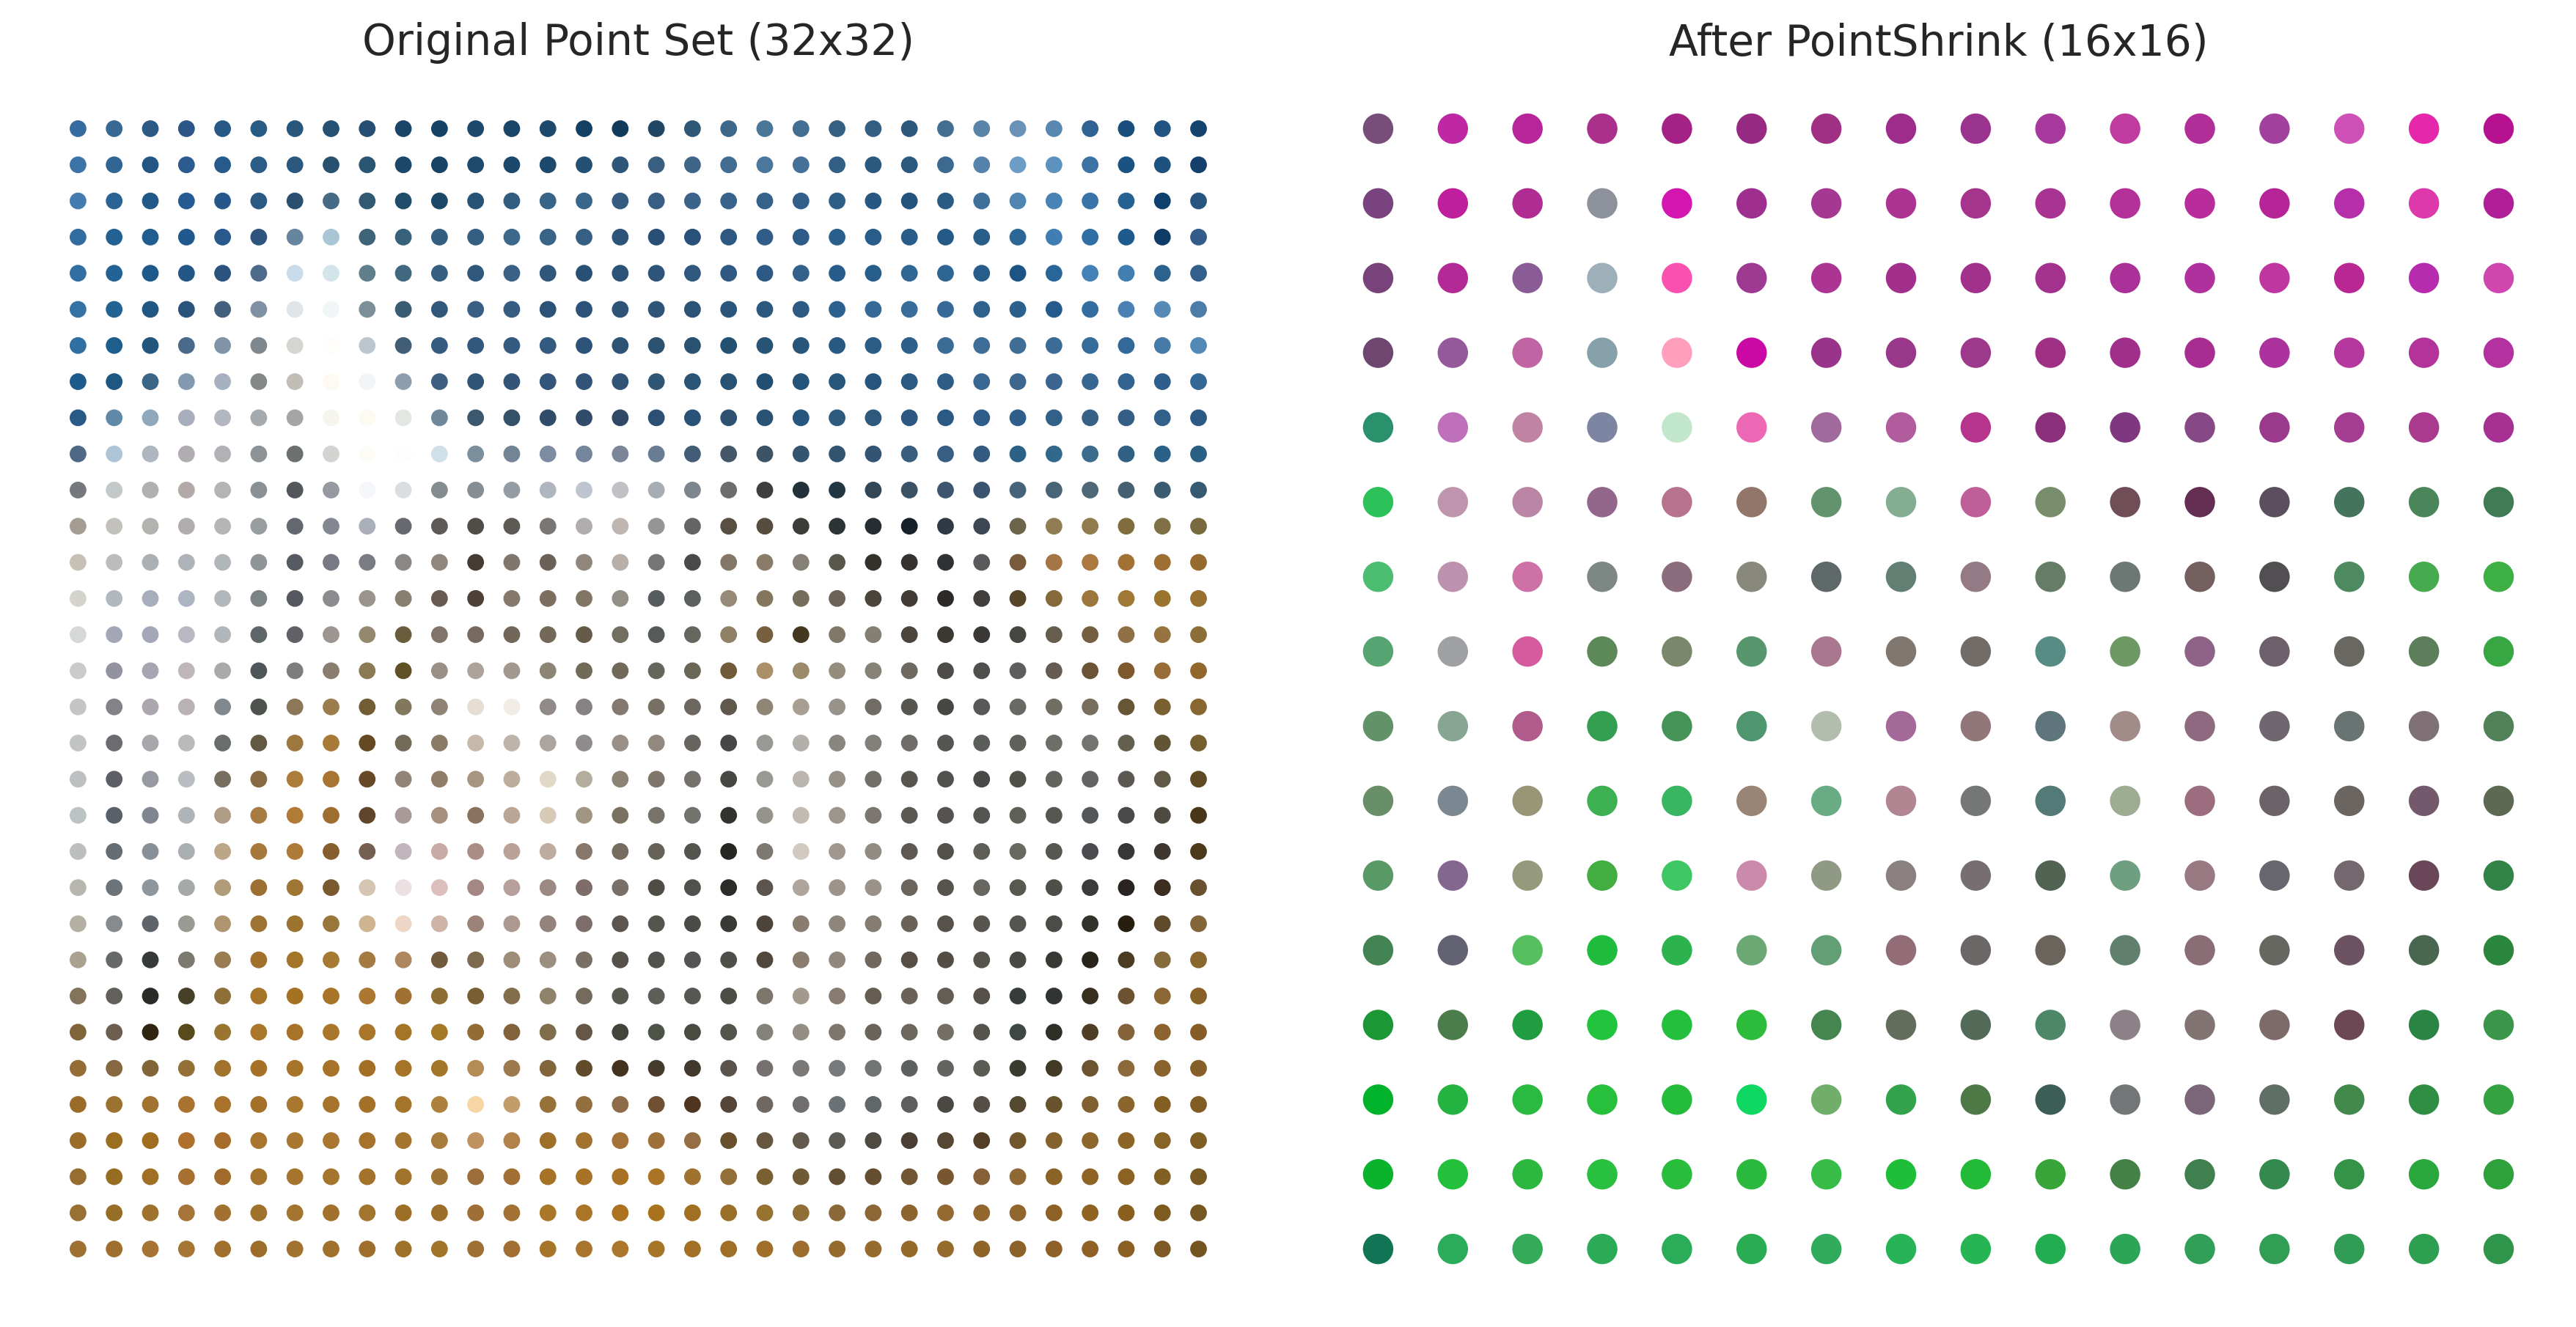

In [4]:
plot_point_cloud_comparison(
    coords_before=coords_orig, colors_before=colors_orig,
    coords_after=coords_shrink, colors_after=colors_shrink,
    titles=['Original Point Set (32x32)', 'After PointShrink (16x16)'],
    save_path='../paper/figures/02_point_shrink.png'
)